### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 3 - Classificação supervisionada com SVM e Random Forest

**Objetivo geral - Treinamento e comparação de modelos supervisionados para triagem de indícios de câncer de mama**

Preparar a base tratada para modelagem, evitar vazamento de informação, treinar modelos supervisionados e comparar os resultados com foco em `recall`, priorizando a redução de falsos negativos no contexto de triagem em saúde.

---

## Sumário da Parte 3

**Fluxo principal da Parte 3**

**Item 1 - Carregamento da base e definição do target**

- **1.1 - Leitura da base tratada final**
- **1.2 - Definição da variável alvo `CANCER_MAMA_NIVEL`**
- **1.3 - Avaliação inicial da distribuição das classes**

**Item 2 - Seleção de features e prevenção de vazamento**

- **2.1 - Definição das colunas candidatas para modelagem**
- **2.2 - Remoção de variáveis que poderiam causar vazamento de informação**
- **2.3 - Separação entre variáveis numéricas e categóricas de baixa cardinalidade**
- **2.4 - Verificação de valores ausentes nas features selecionadas**

**Item 3 - Separação treino/teste**

- **3.1 - Divisão estratificada entre treino e teste**
- **3.2 - Conferência da proporção das classes nos conjuntos gerados**

**Item 4 - Pré-processamento com `ColumnTransformer`**

- **4.1 - Imputação e padronização das variáveis numéricas**
- **4.2 - Imputação e codificação one-hot das variáveis categóricas**
- **4.3 - Montagem do pré-processador dentro do fluxo de `Pipeline`**

**Item 5 - SVM base**

- **5.1 - Treinamento do `LinearSVC` com parâmetros base**
- **5.2 - Uso do `class_weight='balanced'` para lidar com desbalanceamento**

**Item 6 - Random Forest com ajuste de threshold**

- **6.1 - Treinamento do modelo de validação do Random Forest**
- **6.2 - Cálculo da curva de `precision-recall`**
- **6.3 - Escolha do threshold priorizando recall alto**
- **6.4 - Treinamento final do Random Forest na base completa de treino**

**Item 7 - Avaliação inicial no conjunto de teste**

- **7.1 - Avaliação do SVM base**
- **7.2 - Avaliação do Random Forest com threshold ajustado**
- **7.3 - Cálculo de accuracy, precision, recall, F1-score e matriz de confusão**

**Item 8 - Comparação inicial dos modelos**

- **8.1 - Comparação tabular das métricas do SVM base e do Random Forest**
- **8.2 - Visualização das matrizes de confusão**
- **8.3 - Conclusão da etapa inicial sem tuning**

---

**Etapa complementar - realizada após a Parte 4 do trabalho estar pronta**

**Item 9 - Tuning leve do SVM**

- **9.1 - Criação de amostra estratificada para viabilizar o tuning**
- **9.2 - Configuração do `GridSearchCV` com validação cruzada estratificada**
- **9.3 - Seleção dos melhores hiperparâmetros usando `recall` como métrica principal**

**Item 10 - Tuning leve do Random Forest**

- **10.1 - Recuperação do tuning leve do Random Forest existente na versão anterior**
- **10.2 - Configuração do `GridSearchCV` variando árvores, profundidade e folhas mínimas**
- **10.3 - Seleção dos melhores hiperparâmetros usando `recall` como métrica principal**

**Item 11 - Avaliação dos modelos com tuning**

- **11.1 - Treinamento dos melhores modelos na base completa de treino**
- **11.2 - Avaliação do SVM e do Random Forest com tuning no conjunto de teste**
- **11.3 - Comparação dos modelos com tuning com os resultados do SVM base e do Random Forest inicial**

**Conclusão da Parte 3**

- **Síntese dos resultados obtidos e indicação dos tunings complementares adicionados após a Parte 4**


#### Item 1 - Carregamento da base e definição do target

Nesta etapa carregamos a base tratada e criamos a variável binária `TARGET`:
- `0` para casos sem indício
- `1` para casos com indício (`CANCER_MAMA_NIVEL > 0`)

Também verificamos dimensões da base e distribuição das classes.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

candidate_paths = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
    Path('/content/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/ia_tech_challenge_01/2025_tratado.parquet'),
]

path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if path is None:
    searched = '\n'.join(f'- {candidate}' for candidate in candidate_paths)
    raise FileNotFoundError(
        'Arquivo de base tratada não encontrado. Verifique onde o arquivo '
        "'2025_tratado.parquet' foi salvo e ajuste o caminho na célula.\n"
        f'Caminhos verificados:\n{searched}'
    )

print(f'Arquivo localizado em: {path.resolve()}')
dados = pd.read_parquet(path)

TARGET = 'TARGET'
dados[TARGET] = (dados['CANCER_MAMA_NIVEL'] > 0).astype(int)

print('Dimensões da base tratada:', dados.shape)
print('\nDistribuição do target:')
print(dados[TARGET].value_counts().sort_index())
print('\nProporção do target:')
print(dados[TARGET].value_counts(normalize=True).sort_index().rename('proporcao'))

Arquivo localizado em: /Users/igorcarletti/Development/workspace/trabalho/2025_tratado.parquet
Dimensões da base tratada: (857726, 76)

Distribuição do target:
TARGET
0    848560
1      9166
Name: count, dtype: int64

Proporção do target:
TARGET
0    0.989314
1    0.010686
Name: proporcao, dtype: float64


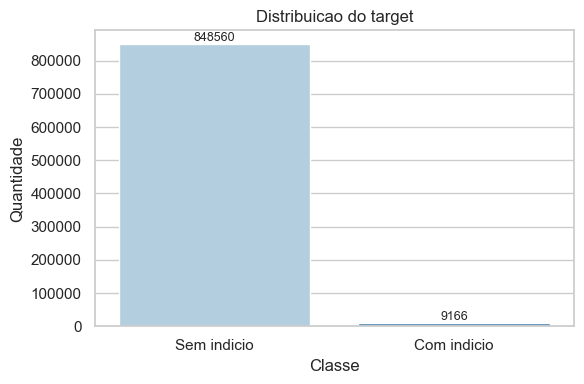

In [2]:
plot_df = dados[TARGET].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
plot_df['Classe'] = plot_df['Classe'].map({0: 'Sem indicio', 1: 'Com indicio'})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_df, x='Classe', y='Quantidade', hue='Classe', palette='Blues', legend=False)
ax.set_title('Distribuicao do target')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

#### Item 2 - Seleção de features e prevenção de vazamento

A seleção de atributos prioriza variáveis administrativas e demográficas, evitando colunas diretamente associadas ao diagnóstico detalhado para reduzir risco de vazamento.


In [3]:
feature_candidates = [
    'IDADE_ANOS',
    'DIAS_PERM',
    'QT_DIARIAS',
    'UTI_MES_IN',
    'UTI_MES_AN',
    'UTI_MES_AL',
    'UTI_MES_TO',
    'UTI_INT_IN',
    'UTI_INT_AN',
    'UTI_INT_AL',
    'UTI_INT_TO',
    'DIAR_ACOM',
    'SEXO',
    'RACA_COR',
    'GESTRISCO',
    'CONTRACEP1',
    'CONTRACEP2',
    'PROC_REA',
]

leakage_columns = [
    'CANCER_MAMA_NIVEL',
    'DIAG_PRINC',
    'DIAGSEC1',
    'DIAGSEC2',
    'DIAGSEC3',
    'DIAGSEC4',
    'DIAGSEC5',
    'DIAGSEC6',
    'DIAGSEC7',
    'CID_MORTE',
    'DIAG_PRINC_GRUPO',
]

features = [col for col in feature_candidates if col in dados.columns]
leakage_present = [col for col in leakage_columns if col in dados.columns]

numerical_features = [col for col in features if dados[col].dtype.kind in 'biufc']
categorical_features = [col for col in features if col not in numerical_features]

low_cardinality_features = []
high_cardinality_features = []
for col in categorical_features:
    nunique = dados[col].nunique(dropna=False)
    if nunique <= 20:
        low_cardinality_features.append(col)
    else:
        high_cardinality_features.append(col)

selected_features = numerical_features + low_cardinality_features
X = dados[selected_features].copy()
y = dados[TARGET].copy()

print('Features selecionadas para modelagem:')
print(selected_features)
print('\nColunas sensíveis identificadas e excluídas:')
print(leakage_present)
print('\nCategóricas excluídas por alta cardinalidade:')
print(high_cardinality_features)
print('\nDimensões de X e y:', X.shape, y.shape)

Features selecionadas para modelagem:
['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM', 'SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']

Colunas sensíveis identificadas e excluídas:
['CANCER_MAMA_NIVEL', 'DIAG_PRINC', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'CID_MORTE', 'DIAG_PRINC_GRUPO']

Categóricas excluídas por alta cardinalidade:
['PROC_REA']

Dimensões de X e y: (857726, 17) (857726,)


In [4]:
print('\nValores ausentes por coluna:')
print(X.isna().sum().sort_values(ascending=False))


Valores ausentes por coluna:
IDADE_ANOS    0
UTI_INT_AL    0
CONTRACEP1    0
GESTRISCO     0
RACA_COR      0
SEXO          0
DIAR_ACOM     0
UTI_INT_TO    0
UTI_INT_AN    0
DIAS_PERM     0
UTI_INT_IN    0
UTI_MES_TO    0
UTI_MES_AL    0
UTI_MES_AN    0
UTI_MES_IN    0
QT_DIARIAS    0
CONTRACEP2    0
dtype: int64


#### Item 3 - Separação treino/teste

Utilizamos `train_test_split` com estratificação (`stratify=y`) para manter a mesma proporção de classes nos dois conjuntos.


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('\nProporção de classes no treino:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nProporção de classes no teste:')
print(y_test.value_counts(normalize=True).sort_index())

Treino: (686180, 17) Teste: (171546, 17)

Proporção de classes no treino:
TARGET
0    0.989313
1    0.010687
Name: proportion, dtype: float64

Proporção de classes no teste:
TARGET
0    0.989315
1    0.010685
Name: proportion, dtype: float64


#### Item 4 - Pré-processamento com `ColumnTransformer`

Como o SVM é sensível à escala dos dados, aplicamos `StandardScaler` nas variáveis numéricas.

Esse fluxo é organizado em um `Pipeline`, evitando vazamento entre treino e teste.


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_features),
])

print('Pré-processador montado com sucesso.')
print('Numéricas:', numerical_features)
print('Categóricas one-hot:', low_cardinality_features)

Pré-processador montado com sucesso.
Numéricas: ['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM']
Categóricas one-hot: ['SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']


#### Item 5 - SVM base

Primeiro treinamos uma versão simples do SVM, usando uma configuração fixa do `LinearSVC`.

Esse modelo serve como referência direta para a comparação inicial com o Random Forest.


In [7]:
from sklearn.base import clone
from sklearn.svm import LinearSVC

svm_base = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)),
])

svm_base.fit(X_train, y_train)
print('SVM base treinado com sucesso')


SVM base treinado com sucesso


#### Item 6 - Random Forest com ajuste de threshold

Em seguida treinamos o Random Forest usando o mesmo fluxo da parte 4: modelo de validação, curva de `precision-recall` e escolha de threshold que mantém recall alto com a melhor precision possível.

Essa estratégia é mais adequada ao problema porque o objetivo principal é reduzir falsos negativos.


In [8]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

X_fit_rf, X_val_rf, y_fit_rf, y_val_rf = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

def calcular_metricas_por_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    rows = []
    for threshold, precision, recall, f1 in zip(thresholds, precisions[:-1], recalls[:-1], f1_scores):
        rows.append({
            'Threshold': float(threshold),
            'Precision': float(precision),
            'Recall': float(recall),
            'F1': float(f1),
        })
    return pd.DataFrame(rows)

def selecionar_threshold_por_precision_com_recall_alto(metricas_threshold, recall_minimo=0.75):
    candidatos = metricas_threshold[metricas_threshold['Recall'] >= recall_minimo].copy()

    if candidatos.empty:
        candidatos = metricas_threshold.copy()
        print(
            f"Nenhum threshold atingiu recall mínimo de {recall_minimo:.2f}. "
            "Usando o melhor recall disponível."
        )
        candidatos = candidatos.sort_values(
            by=['Recall', 'Precision', 'F1'],
            ascending=[False, False, False],
        )
    else:
        candidatos = candidatos.sort_values(
            by=['Precision', 'Recall', 'F1'],
            ascending=[False, False, False],
        )

    linha = candidatos.iloc[0]
    return (
        float(linha['Threshold']),
        float(linha['Precision']),
        float(linha['Recall']),
        float(linha['F1']),
    )

rf_validation_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])
rf_validation_model.fit(X_fit_rf, y_fit_rf)

val_scores_rf = rf_validation_model.predict_proba(X_val_rf)[:, 1]
rf_threshold_df = calcular_metricas_por_threshold(y_val_rf, val_scores_rf)
rf_threshold_df['Modelo'] = 'Random Forest'

best_threshold_rf, best_precision_rf, best_recall_rf, best_f1_rf = selecionar_threshold_por_precision_com_recall_alto(
    rf_threshold_df,
    recall_minimo=0.75,
)

print(f'Melhor threshold para Random Forest: {best_threshold_rf:.4f}')
print(f'Precision validação: {best_precision_rf:.4f}')
print(f'Recall validação: {best_recall_rf:.4f}')
print(f'F1 validação: {best_f1_rf:.4f}')

best_rf = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])
best_rf.fit(X_train, y_train)
print('Random Forest treinado com sucesso')

rf_threshold_df.sort_values(by=['F1', 'Recall', 'Precision'], ascending=[False, False, False]).head(10)


Melhor threshold para Random Forest: 0.6506
Precision validação: 0.0532
Recall validação: 0.7505
F1 validação: 0.0994
Random Forest treinado com sucesso


,Threshold,Precision,Recall,F1,Modelo
33080,0.806363,0.092797,0.331970,0.145048,Random Forest
33079,0.806315,0.092762,0.331970,0.145005,Random Forest
33078,0.806194,0.092744,0.331970,0.144984,Random Forest
33077,0.806114,0.092617,0.332652,0.144893,Random Forest
33076,0.806050,0.092459,0.332652,0.144700,Random Forest
33075,0.806013,0.092442,0.332652,0.144678,Random Forest
33081,0.806380,0.092487,0.330607,0.144539,Random Forest
33089,0.806964,0.092646,0.327198,0.144404,Random Forest
33082,0.806454,0.092349,0.329925,0.144305,Random Forest
33096,0.807489,0.092987,0.321745,0.144276,Random Forest


#### Item 7 - Avaliação inicial no conjunto de teste

Com os modelos definidos, avaliamos primeiro as abordagens iniciais: SVM base e Random Forest.

As métricas analisadas são:
- `accuracy`
- `precision`
- `recall`
- `f1-score`
- matriz de confusão


In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

modelos_finais = {
    'SVM base': {
        'modelo': svm_base,
        'threshold': None,
        'configuracao': 'LinearSVC com class_weight=balanced',
    },
    'Random Forest': {
        'modelo': best_rf,
        'threshold': best_threshold_rf,
        'configuracao': f'threshold={best_threshold_rf:.4f}',
    },
}

resultados = []
matrizes = {}

for nome, config in modelos_finais.items():
    modelo = config['modelo']
    threshold = config['threshold']
    configuracao = config['configuracao']

    if threshold is None:
        y_pred = modelo.predict(X_test)
    else:
        y_scores = modelo.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

    matriz = confusion_matrix(y_test, y_pred)
    matrizes[nome] = matriz

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Configuracao': configuracao,
    })

    print(f'--- {nome} ---')
    print(f'Configuração: {configuracao}')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

resultados_df = (
    pd.DataFrame(resultados)
    .set_index('Modelo')
    .sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
    .round(4)
)

resultados_df


--- SVM base ---
Configuração: LinearSVC com class_weight=balanced
              precision    recall  f1-score   support

           0       1.00      0.69      0.82    169713
           1       0.03      0.93      0.06      1833

    accuracy                           0.70    171546
   macro avg       0.52      0.81      0.44    171546
weighted avg       0.99      0.70      0.81    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  117731   51982
Real 1     133    1700

--- Random Forest ---
Configuração: threshold=0.6506
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    169713
           1       0.05      0.77      0.10      1833

    accuracy                           0.84    171546
   macro avg       0.52      0.81      0.50    171546
weighted avg       0.99      0.84      0.91    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  143226   26487
Real 1     414    1419



,Accuracy,Precision,Recall,F1,Configuracao
Modelo,,,,,
SVM base,0.6962,0.0317,0.9274,0.0612,LinearSVC com class_weight=balanced
Random Forest,0.8432,0.0508,0.7741,0.0954,threshold=0.6506


#### Item 8 - Comparação inicial dos modelos

A tabela abaixo resume a comparação entre o SVM base e o Random Forest.
No contexto de triagem em saúde, o principal critério é o `recall`, sem ignorar o trade-off com `precision`.


,Threshold,Precision,Recall,F1,Modelo
33080,0.806363,0.092797,0.331970,0.145048,Random Forest
33079,0.806315,0.092762,0.331970,0.145005,Random Forest
33078,0.806194,0.092744,0.331970,0.144984,Random Forest
33077,0.806114,0.092617,0.332652,0.144893,Random Forest
33076,0.806050,0.092459,0.332652,0.144700,Random Forest
33075,0.806013,0.092442,0.332652,0.144678,Random Forest
33081,0.806380,0.092487,0.330607,0.144539,Random Forest
33089,0.806964,0.092646,0.327198,0.144404,Random Forest
33082,0.806454,0.092349,0.329925,0.144305,Random Forest
33096,0.807489,0.092987,0.321745,0.144276,Random Forest


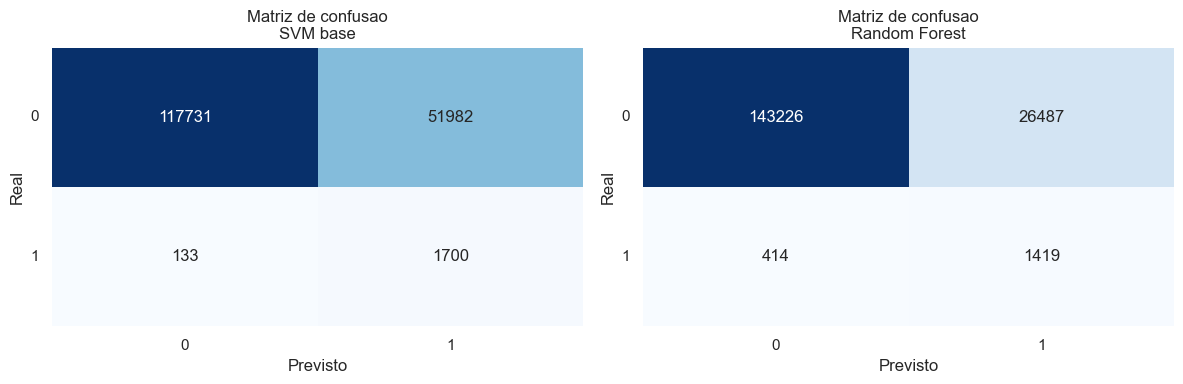

In [10]:
display(
    rf_threshold_df
    .sort_values(by=['F1', 'Recall', 'Precision'], ascending=[False, False, False])
    .head(10)
)

resultados_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
}).highlight_max(subset=['Recall'], color='#d9ead3')

fig, axes = plt.subplots(1, len(matrizes), figsize=(12, 4))
if len(matrizes) == 1:
    axes = [axes]

for ax, (nome, matriz) in zip(axes, matrizes.items()):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de confusao\n{nome}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()


#### Conclusão da etapa inicial sem tuning

Na comparação inicial, antes da etapa complementar de tuning, o critério de escolha precisa seguir a lógica do problema de saúde: o melhor modelo é aquele que apresenta o menor número de **falsos negativos**. Neste contexto, falso negativo significa deixar de identificar um caso que realmente tinha indício positivo.

Pela matriz de confusão, o `SVM base` teve apenas **133 falsos negativos**, identificando **1.700 dos 1.833 casos positivos** no conjunto de teste. Isso corresponde a um **recall de 0,9274**, o maior da etapa inicial.

O `Random Forest` com threshold ajustado teve **414 falsos negativos**, identificando **1.419 dos 1.833 casos positivos**, com **recall de 0,7741**. Apesar de apresentar melhor **accuracy de 0,8432**, melhor **precision de 0,0508** e melhor **F1-score de 0,0954**, ele deixou passar mais casos positivos do que o SVM.

Assim, para o objetivo de triagem em saúde, o vencedor da etapa inicial sem tuning é o **SVM base**, porque apresentou o menor índice de falsos negativos. O `Random Forest` permanece como alternativa mais equilibrada quando o objetivo for reduzir falsos positivos, mas não é o melhor modelo quando a prioridade é não deixar casos positivos passarem.


#### Etapa complementar - Item 9 - Tuning leve do SVM

Esta etapa foi adicionada depois que a Parte 4 do trabalho já estava pronta. Ela funciona como uma complementação da Parte 3, separada do fluxo principal de treinamento e comparação inicial.

Aqui aplicamos uma busca curta de hiperparâmetros com validação cruzada estratificada. Como a base pode ser grande, usamos uma amostra estratificada do treino para tornar o ajuste viável sem perder representatividade.


In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

svm_train_size = min(50000, len(X_train))
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=svm_train_size,
    random_state=42,
    stratify=y_train,
)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)),
])

svm_param_grid = {
    'classifier__C': [0.5, 1.0, 2.0],
    'classifier__loss': ['squared_hinge'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

svm_search.fit(X_train_svm, y_train_svm)

print('Melhores parâmetros SVM:', svm_search.best_params_)
print(f"Melhor recall médio (CV): {svm_search.best_score_:.4f}")

svm_tuning_df = pd.DataFrame(svm_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
svm_tuning_df.head(10)


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros SVM: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}
Melhor recall médio (CV): 0.9270


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


#### Etapa complementar - Item 10 - Tuning leve do Random Forest

Na sequência do tuning do SVM, recuperamos também o tuning leve do Random Forest que existia na versão anterior da Parte 3.

A busca varia quantidade de árvores, profundidade máxima e tamanho mínimo das folhas, mantendo `recall` como métrica principal.


In [12]:
rf_tuning_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1,
    )),
])

rf_param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [8, 12],
    'classifier__min_samples_leaf': [5, 10],
}

rf_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_train_size = min(30000, len(X_train))
X_train_rf, _, y_train_rf, _ = train_test_split(
    X_train,
    y_train,
    train_size=rf_train_size,
    random_state=42,
    stratify=y_train,
)

rf_search.fit(X_train_rf, y_train_rf)

print('Melhores parâmetros Random Forest:', rf_search.best_params_)
print(f"Melhor recall médio (CV): {rf_search.best_score_:.4f}")

rf_grid_tuning_df = pd.DataFrame(rf_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
rf_grid_tuning_df.head(10)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros Random Forest: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
Melhor recall médio (CV): 0.8567


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.763240,0.078317,8


#### Etapa complementar - Item 11 - Avaliação dos modelos com tuning

Depois dos tunings complementares, treinamos os melhores modelos encontrados pelo `GridSearchCV` na base completa de treino e comparamos o desempenho no conjunto de teste com os resultados iniciais da Parte 3.


In [13]:
best_svm = svm_search.best_estimator_
best_rf_tuning = rf_search.best_estimator_

best_svm.fit(X_train, y_train)
best_rf_tuning.fit(X_train, y_train)

modelos_tuning = {
    'SVM com tuning': {
        'modelo': best_svm,
        'configuracao': str(svm_search.best_params_),
    },
    'Random Forest com tuning': {
        'modelo': best_rf_tuning,
        'configuracao': str(rf_search.best_params_),
    },
}

resultados_tuning = []
matrizes_tuning = {}

for nome, config in modelos_tuning.items():
    modelo = config['modelo']
    y_pred = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, y_pred)
    matrizes_tuning[nome] = matriz

    resultados_tuning.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Configuracao': config['configuracao'],
    })

    print(f'--- {nome} ---')
    print(f"Melhores parâmetros: {config['configuracao']}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

resultado_tuning_df = pd.DataFrame(resultados_tuning).set_index('Modelo').round(4)

comparacao_com_tuning = pd.concat([resultados_df, resultado_tuning_df])
comparacao_com_tuning = comparacao_com_tuning.sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)

print('Resultados do tuning do SVM:')
display(svm_tuning_df.head(10))
print('Resultados do tuning do Random Forest:')
display(rf_grid_tuning_df.head(10))

comparacao_com_tuning


--- SVM com tuning ---
Melhores parâmetros: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}
              precision    recall  f1-score   support

           0       1.00      0.69      0.82    169713
           1       0.03      0.93      0.06      1833

    accuracy                           0.70    171546
   macro avg       0.52      0.81      0.44    171546
weighted avg       0.99      0.70      0.81    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  117731   51982
Real 1     133    1700

--- Random Forest com tuning ---
Melhores parâmetros: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
              precision    recall  f1-score   support

           0       1.00      0.72      0.84    169713
           1       0.03      0.92      0.07      1833

    accuracy                           0.73    171546
   macro avg       0.52      0.82      0.45    171546
weighted avg       0.99      0.73      0.83    171546

M

,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


Resultados do tuning do Random Forest:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.763240,0.078317,8


,Accuracy,Precision,Recall,F1,Configuracao
Modelo,,,,,
SVM base,0.6962,0.0317,0.9274,0.0612,LinearSVC com class_weight=balanced
SVM com tuning,0.6962,0.0317,0.9274,0.0612,"{'classifier__C': 0.5, 'classifier__loss': 'sq..."
Random Forest com tuning,0.7250,0.0347,0.9214,0.0668,"{'classifier__max_depth': 8, 'classifier__min_..."
Random Forest,0.8432,0.0508,0.7741,0.0954,threshold=0.6506


#### Conclusão da Parte 3

Como este problema está inserido em um contexto de saúde, a escolha do melhor algoritmo deve priorizar o menor número de **falsos negativos**. Um falso negativo representa um caso com indício positivo que o modelo deixou de identificar, o que é mais crítico do que gerar falsos positivos em um cenário de triagem.

Na etapa principal da Parte 3, sem tuning complementar, o `SVM base` foi o vencedor por esse critério. Ele apresentou apenas **133 falsos negativos**, identificando **1.700 dos 1.833 casos positivos** no conjunto de teste, com **recall de 0,9274**. O `Random Forest` com threshold ajustado teve **414 falsos negativos** e **recall de 0,7741**, embora tenha obtido melhor accuracy, precision e F1-score.

A etapa complementar foi adicionada depois que a Parte 4 do trabalho já estava pronta. Nela, o tuning leve do `SVM` com `GridSearchCV` encontrou `C=0.5` e `loss='squared_hinge'`, mas o desempenho no teste ficou igual ao SVM base: **133 falsos negativos**, **recall de 0,9274**, **precision de 0,0317** e **F1-score de 0,0612**. Portanto, o tuning do SVM não trouxe ganho prático em relação à versão base.

Também foi recuperado o tuning leve do `Random Forest` que existia na versão anterior da Parte 3. O melhor conjunto encontrado foi `max_depth=8`, `min_samples_leaf=5` e `n_estimators=150`. Esse modelo teve **144 falsos negativos**, com **recall de 0,9214**, ficando próximo do SVM, mas ainda deixando passar mais casos positivos. Além disso, apresentou **accuracy de 0,7250**, **precision de 0,0347** e **F1-score de 0,0668**.

Considerando toda a Parte 3 e adotando o menor número de falsos negativos como critério principal, o melhor algoritmo é o **SVM base**. O `SVM com tuning` empatou com ele nos resultados, mas não trouxe melhoria adicional; por isso, a versão base é preferível por ser mais simples. O `Random Forest com tuning` ficou muito próximo em recall, mas ainda teve mais falsos negativos. Já o `Random Forest` com threshold ajustado foi o modelo mais equilibrado em accuracy, precision e F1-score, mas não é o vencedor para o objetivo clínico de reduzir casos positivos não detectados.
